<a href="https://colab.research.google.com/github/JeyasriHariharan/Cross_market_analysis/blob/main/cross_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================
# CELL 1: INSTALL ALL REQUIRED PACKAGES
# ================================================
!pip install yfinance -q
!pip install streamlit -q
!pip install plotly -q
!pip install streamlit-option-menu -q
!pip install pyngrok -q

print("All packages installed! ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 12.5 MB/s eta 0:00:00
All packages installed! ✅


In [ ]:
# ================================================
# CELL 2: IMPORT ALL LIBRARIES
# ================================================
import requests
import pandas as pd
import yfinance as yf
import sqlite3
import time
import warnings
warnings.filterwarnings('ignore')

print("All imports done! ✅")

All imports done! ✅


In [ ]:
# ================================================
# CELL 3: FETCH CRYPTOCURRENCY METADATA
# From CoinGecko API
# ================================================
def fetch_crypto_metadata():
    print("Fetching crypto metadata...")
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "usd",
        "per_page": 250,
        "order": "market_cap_desc",
        "page": 1,
        "sparkline": False
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data)
    df = df[[
        'id', 'symbol', 'name', 'current_price',
        'market_cap', 'market_cap_rank', 'total_volume',
        'circulating_supply', 'total_supply', 'ath', 'atl',
        'last_updated'
    ]]
    df['last_updated'] = pd.to_datetime(
        df['last_updated']
    ).dt.date
    df.rename(columns={'last_updated': 'date'}, inplace=True)
    print(f"Fetched {len(df)} cryptocurrencies! ✅")
    return df

df_crypto = fetch_crypto_metadata()
print("\nTop 5 Cryptocurrencies:")
print(df_crypto[['name', 'market_cap_rank', 'current_price']].head())

Fetching crypto metadata...
Fetched 250 cryptocurrencies! ✅

Top 5 Cryptocurrencies:
       name  market_cap_rank  current_price
0   Bitcoin                1   70582.000000
1  Ethereum                2    1991.440000
2    Tether                3       0.998341
3       BNB                4     685.320000
4       XRP                5       1.270000


In [ ]:
# ================================================
# CELL 4: FETCH TOP 3 COINS HISTORICAL PRICES
# 1 year daily price data
# ================================================
def fetch_crypto_prices(coin_id):
    print(f"Fetching prices for {coin_id}...")
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {"vs_currency": "usd", "days": 365}
    response = requests.get(url, params=params)
    data = response.json()
    prices = data['prices']
    df = pd.DataFrame(prices, columns=['timestamp', 'price_usd'])
    df['date'] = pd.to_datetime(
        df['timestamp'], unit='ms'
    ).dt.date
    df['coin_id'] = coin_id
    df = df[['coin_id', 'date', 'price_usd']]
    time.sleep(2)
    print(f"Fetched {len(df)} records! ✅")
    return df

# Get top 3 coins
top3 = df_crypto.nsmallest(3, 'market_cap_rank')['id'].tolist()
print(f"Top 3 coins: {top3}")

# Fetch prices
all_prices = []
for coin in top3:
    prices = fetch_crypto_prices(coin)
    all_prices.append(prices)

df_crypto_prices = pd.concat(all_prices, ignore_index=True)
print(f"\nTotal price records: {len(df_crypto_prices)}")
print(df_crypto_prices.head())

Top 3 coins: ['bitcoin', 'ethereum', 'tether']
Fetching prices for bitcoin...
Fetched 366 records! ✅
Fetching prices for ethereum...
Fetched 366 records! ✅
Fetching prices for tether...
Fetched 366 records! ✅

Total price records: 1098
   coin_id        date      price_usd
0  bitcoin  2025-06-03  105884.742632
1  bitcoin  2025-06-04  105434.477451
2  bitcoin  2025-06-05  104812.918219
3  bitcoin  2025-06-06  101650.738755
4  bitcoin  2025-06-07  104409.749680


In [ ]:
# ================================================
# CELL 5: FETCH OIL PRICES
# WTI Crude Oil from GitHub Dataset
# ================================================
def fetch_oil_prices():
    print("Fetching oil prices...")
    url = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-daily.csv"
    df = pd.read_csv(url)
    df.columns = ['date', 'price_usd']
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df[
        (df['date'] >= pd.to_datetime('2020-01-01').date()) &
        (df['date'] <= pd.to_datetime('2026-01-01').date())
    ]
    print(f"Fetched {len(df)} oil price records! ✅")
    return df

df_oil = fetch_oil_prices()
print("\nOil Price Sample:")
print(df_oil.head())

Fetching oil prices...
Fetched 1500 oil price records! ✅

Oil Price Sample:
            date  price_usd
8569  2020-01-02      61.17
8570  2020-01-03      63.00
8571  2020-01-06      63.27
8572  2020-01-07      62.70
8573  2020-01-08      59.65


In [ ]:
# ================================================
# CELL 6: FETCH STOCK PRICES
# S&P 500, NASDAQ, NIFTY from Yahoo Finance
# ================================================
def fetch_stock_prices():
    print("Fetching stock prices...")
    tickers = ["^GSPC", "^IXIC", "^NSEI"]
    all_stocks = []

    for ticker in tickers:
        print(f"Fetching {ticker}...")
        stock = yf.download(
            ticker,
            start="2020-01-01",
            end="2025-09-30",
            progress=False
        )
        stock = stock.reset_index()
        stock['ticker'] = ticker
        stock.columns = [
            'date', 'close', 'high', 'low',
            'open', 'volume', 'ticker'
        ]
        stock['date'] = pd.to_datetime(stock['date']).dt.date
        all_stocks.append(stock)
        time.sleep(1)

    df = pd.concat(all_stocks, ignore_index=True)
    print(f"Fetched {len(df)} stock records! ✅")
    return df

df_stocks = fetch_stock_prices()
print("\nStock Price Sample:")
print(df_stocks.head())

Fetching stock prices...
Fetching ^GSPC...
Fetching ^IXIC...
Fetching ^NSEI...
Fetched 4309 stock records! ✅

Stock Price Sample:
         date        close         high          low         open      volume  \
0  2020-01-02  3257.850098  3258.139893  3235.530029  3244.669922  3459930000   
1  2020-01-03  3234.850098  3246.149902  3222.340088  3226.360107  3484700000   
2  2020-01-06  3246.280029  3246.840088  3214.639893  3217.550049  3702460000   
3  2020-01-07  3237.179932  3244.909912  3232.429932  3241.860107  3435910000   
4  2020-01-08  3253.050049  3267.070068  3236.669922  3238.590088  3726840000   

  ticker  
0  ^GSPC  
1  ^GSPC  
2  ^GSPC  
3  ^GSPC  
4  ^GSPC  


In [ ]:
# ================================================
# CELL 7: CREATE SQLite DATABASE & INSERT DATA
# ================================================
conn = sqlite3.connect('cross_market.db')
cursor = conn.cursor()

# Create tables
cursor.execute("""
    CREATE TABLE IF NOT EXISTS cryptocurrencies (
        id VARCHAR(50) PRIMARY KEY,
        symbol VARCHAR(10),
        name VARCHAR(100),
        current_price DECIMAL(18,6),
        market_cap BIGINT,
        market_cap_rank INT,
        total_volume BIGINT,
        circulating_supply DECIMAL(20,6),
        total_supply DECIMAL(20,6),
        ath DECIMAL(18,6),
        atl DECIMAL(18,6),
        date DATE
    )
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS crypto_prices (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        coin_id VARCHAR(50),
        date DATE,
        price_usd DECIMAL(18,6)
    )
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS oil_prices (
        date DATE PRIMARY KEY,
        price_usd DECIMAL(18,6)
    )
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS stock_prices (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        date DATE,
        open DECIMAL(18,6),
        high DECIMAL(18,6),
        low DECIMAL(18,6),
        close DECIMAL(18,6),
        volume BIGINT,
        ticker VARCHAR(20)
    )
""")

conn.commit()
print("Tables created! ✅")

# Insert data
df_crypto.to_sql('cryptocurrencies', conn,
                 if_exists='replace', index=False)
print("Crypto metadata inserted! ✅")

df_crypto_prices.to_sql('crypto_prices', conn,
                         if_exists='replace', index=False)
print("Crypto prices inserted! ✅")

df_oil.to_sql('oil_prices', conn,
              if_exists='replace', index=False)
print("Oil prices inserted! ✅")

df_stocks.to_sql('stock_prices', conn,
                 if_exists='replace', index=False)
print("Stock prices inserted! ✅")

print("\nAll data inserted successfully! ✅")

Tables created! ✅
Crypto metadata inserted! ✅
Crypto prices inserted! ✅
Oil prices inserted! ✅
Stock prices inserted! ✅

All data inserted successfully! ✅


In [ ]:
# ================================================
# CELL 8: VERIFY DATABASE
# ================================================
print("="*50)
print("DATABASE VERIFICATION")
print("="*50)

tables = ['cryptocurrencies', 'crypto_prices',
          'oil_prices', 'stock_prices']

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) as count FROM {table}", conn
    ).iloc[0]['count']
    print(f"{table}: {count} records")

print("\nDatabase ready! ✅")

DATABASE VERIFICATION
cryptocurrencies: 250 records
crypto_prices: 1098 records
oil_prices: 1500 records
stock_prices: 4309 records

Database ready! ✅


In [ ]:
# ================================================
# CELL 10: SQL QUERIES - CRYPTO PRICES & OIL
# ================================================

print("="*50)
print("SQL QUERIES - CRYPTO PRICES")
print("="*50)

# Query 6: Bitcoin highest price
print("\n6. Bitcoin Highest Price:")
q6 = pd.read_sql("""
    SELECT MAX(price_usd) AS highest_price
    FROM crypto_prices WHERE coin_id = 'bitcoin'
""", conn)
print(q6)

# Query 7: Ethereum avg price
print("\n7. Ethereum Average Price:")
q7 = pd.read_sql("""
    SELECT ROUND(AVG(price_usd),2) AS avg_price
    FROM crypto_prices WHERE coin_id = 'ethereum'
""", conn)
print(q7)

# Query 8: Bitcoin trend
print("\n8. Bitcoin Price Trend (Recent Month):")
q8 = pd.read_sql("""
    SELECT date, price_usd FROM crypto_prices
    WHERE coin_id = 'bitcoin'
    ORDER BY date DESC LIMIT 30
""", conn)
print(q8.head())

print("\n" + "="*50)
print("SQL QUERIES - OIL PRICES")
print("="*50)

# Query 9: Highest oil price
print("\n9. Highest Oil Price (Last 5 Years):")
q9 = pd.read_sql("""
    SELECT MAX(price_usd) AS highest_oil_price
    FROM oil_prices
""", conn)
print(q9)

# Query 10: Avg oil per year
print("\n10. Average Oil Price Per Year:")
q10 = pd.read_sql("""
    SELECT strftime('%Y', date) AS year,
    ROUND(AVG(price_usd),2) AS avg_price
    FROM oil_prices GROUP BY year ORDER BY year
""", conn)
print(q10)

# Query 11: COVID crash
print("\n11. Oil During COVID Crash (Mar-Apr 2020):")
q11 = pd.read_sql("""
    SELECT date, price_usd FROM oil_prices
    WHERE date BETWEEN '2020-03-01' AND '2020-04-30'
    ORDER BY date
""", conn)
print(q11.head(10))

# Query 12: Oil volatility
print("\n12. Oil Price Volatility Per Year:")
q12 = pd.read_sql("""
    SELECT strftime('%Y', date) AS year,
    ROUND(MAX(price_usd)-MIN(price_usd),2) AS volatility
    FROM oil_prices GROUP BY year ORDER BY year
""", conn)
print(q12)

SQL QUERIES - CRYPTO PRICES

6. Bitcoin Highest Price:
   highest_price
0  124773.508231

7. Ethereum Average Price:
   avg_price
0    3027.27

8. Bitcoin Price Trend (Recent Month):
         date     price_usd
0  2026-06-02  71360.325213
1  2026-06-02  70587.188807
2  2026-06-01  73593.371197
3  2026-05-31  73751.067873
4  2026-05-30  73382.718314

SQL QUERIES - OIL PRICES

9. Highest Oil Price (Last 5 Years):
   highest_oil_price
0             123.64

10. Average Oil Price Per Year:
   year  avg_price
0  2020      39.16
1  2021      68.14
2  2022      94.90
3  2023      77.58
4  2024      76.63
5  2025      65.39

11. Oil During COVID Crash (Mar-Apr 2020):
         date  price_usd
0  2020-03-02      46.78
1  2020-03-03      47.27
2  2020-03-04      46.78
3  2020-03-05      45.90
4  2020-03-06      41.14
5  2020-03-09      31.05
6  2020-03-10      34.47
7  2020-03-11      33.13
8  2020-03-12      31.56
9  2020-03-13      31.72

12. Oil Price Volatility Per Year:
   year  volatility
0 

In [ ]:
# ================================================
# CELL 11: SQL QUERIES - STOCKS & CROSS-MARKET
# ================================================

print("="*50)
print("SQL QUERIES - STOCK PRICES")
print("="*50)

# Query 13: NASDAQ highest
print("\n13. NASDAQ Highest Closing Price:")
q13 = pd.read_sql("""
    SELECT MAX(close) AS highest_close
    FROM stock_prices WHERE ticker = '^IXIC'
""", conn)
print(q13)

# Query 14: S&P 500 volatile days
print("\n14. Top 5 Volatile Days for S&P 500:")
q14 = pd.read_sql("""
    SELECT date, ROUND(high-low,2) AS price_diff
    FROM stock_prices WHERE ticker = '^GSPC'
    ORDER BY price_diff DESC LIMIT 5
""", conn)
print(q14)

# Query 15: Monthly avg close
print("\n15. Monthly Average Close Per Ticker:")
q15 = pd.read_sql("""
    SELECT ticker,
    strftime('%Y-%m', date) AS month,
    ROUND(AVG(close),2) AS avg_close
    FROM stock_prices GROUP BY ticker, month
    ORDER BY ticker, month LIMIT 10
""", conn)
print(q15)

print("\n" + "="*50)
print("CROSS-MARKET JOIN QUERIES")
print("="*50)

# Query 16: Bitcoin vs Oil
print("\n16. Bitcoin vs Oil (Monthly Comparison):")
q16 = pd.read_sql("""
    SELECT strftime('%Y-%m', cp.date) AS month,
    ROUND(AVG(cp.price_usd),2) AS bitcoin_avg,
    ROUND(AVG(op.price_usd),2) AS oil_avg
    FROM crypto_prices cp
    JOIN oil_prices op ON cp.date = op.date
    WHERE cp.coin_id = 'bitcoin'
    GROUP BY month ORDER BY month LIMIT 10
""", conn)
print(q16)

# Query 17: Bitcoin vs S&P 500
print("\n17. Bitcoin vs S&P 500:")
q17 = pd.read_sql("""
    SELECT cp.date,
    cp.price_usd AS bitcoin_price,
    sp.close AS sp500_close
    FROM crypto_prices cp
    JOIN stock_prices sp ON cp.date = sp.date
    WHERE cp.coin_id = 'bitcoin'
    AND sp.ticker = '^GSPC'
    ORDER BY cp.date DESC LIMIT 10
""", conn)
print(q17)

# Query 18: Full market snapshot
print("\n18. Daily Market Snapshot (All Markets):")
q18 = pd.read_sql("""
    SELECT cp.date,
    ROUND(cp.price_usd,2) AS bitcoin_price,
    op.price_usd AS oil_price,
    sp500.close AS sp500,
    nifty.close AS nifty
    FROM crypto_prices cp
    LEFT JOIN oil_prices op ON cp.date = op.date
    LEFT JOIN stock_prices sp500
        ON cp.date = sp500.date AND sp500.ticker = '^GSPC'
    LEFT JOIN stock_prices nifty
        ON cp.date = nifty.date AND nifty.ticker = '^NSEI'
    WHERE cp.coin_id = 'bitcoin'
    ORDER BY cp.date DESC LIMIT 10
""", conn)
print(q18)

SQL QUERIES - STOCK PRICES

13. NASDAQ Highest Closing Price:
   highest_close
0   22788.980469

14. Top 5 Volatile Days for S&P 500:
         date  price_diff
0  2025-04-09      532.91
1  2025-04-07      411.53
2  2025-04-08      357.05
3  2025-04-10      237.88
4  2025-04-04      222.24

15. Monthly Average Close Per Ticker:
  ticker    month  avg_close
0  ^GSPC  2020-01    3278.20
1  ^GSPC  2020-02    3277.31
2  ^GSPC  2020-03    2652.39
3  ^GSPC  2020-04    2761.98
4  ^GSPC  2020-05    2919.61
5  ^GSPC  2020-06    3104.66
6  ^GSPC  2020-07    3207.62
7  ^GSPC  2020-08    3391.71
8  ^GSPC  2020-09    3365.52
9  ^GSPC  2020-10    3418.70

CROSS-MARKET JOIN QUERIES

16. Bitcoin vs Oil (Monthly Comparison):
     month  bitcoin_avg  oil_avg
0  2025-06    106076.21    68.43
1  2025-07    115220.79    68.39
2  2025-08    115441.68    64.86
3  2025-09    113184.12    63.96
4  2025-10    114565.08    60.89
5  2025-11     96878.52    60.06
6  2025-12     89130.77    57.97

17. Bitcoin vs S&P

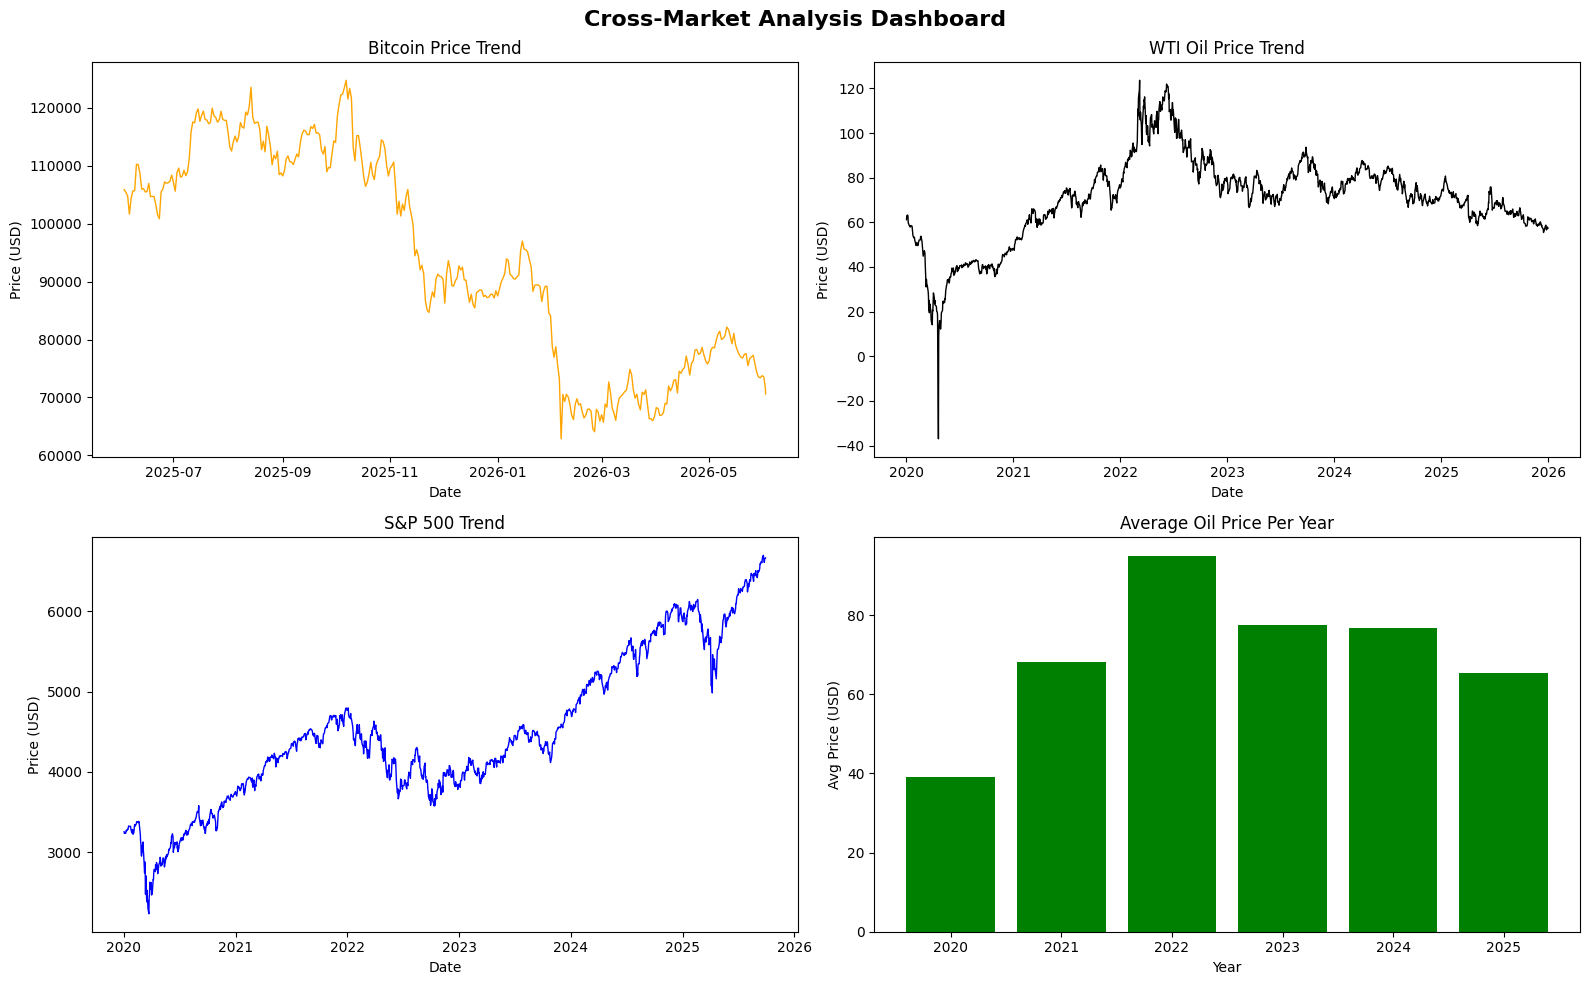

Visualizations Done! ✅


In [ ]:
# ================================================
# CELL 12: DATA VISUALIZATIONS
# ================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cross-Market Analysis Dashboard',
             fontsize=16, fontweight='bold')

# Plot 1: Bitcoin Price Trend
bitcoin_data = pd.read_sql("""
    SELECT date, price_usd FROM crypto_prices
    WHERE coin_id = 'bitcoin' ORDER BY date
""", conn)
bitcoin_data['date'] = pd.to_datetime(bitcoin_data['date'])
axes[0,0].plot(bitcoin_data['date'],
               bitcoin_data['price_usd'],
               color='orange', linewidth=1)
axes[0,0].set_title('Bitcoin Price Trend')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Price (USD)')

# Plot 2: Oil Price Trend
oil_data = pd.read_sql("""
    SELECT date, price_usd FROM oil_prices ORDER BY date
""", conn)
oil_data['date'] = pd.to_datetime(oil_data['date'])
axes[0,1].plot(oil_data['date'],
               oil_data['price_usd'],
               color='black', linewidth=1)
axes[0,1].set_title('WTI Oil Price Trend')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Price (USD)')

# Plot 3: S&P 500 Trend
sp500_data = pd.read_sql("""
    SELECT date, close FROM stock_prices
    WHERE ticker = '^GSPC' ORDER BY date
""", conn)
sp500_data['date'] = pd.to_datetime(sp500_data['date'])
axes[1,0].plot(sp500_data['date'],
               sp500_data['close'],
               color='blue', linewidth=1)
axes[1,0].set_title('S&P 500 Trend')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Price (USD)')

# Plot 4: Avg Oil Price Per Year
oil_yearly = pd.read_sql("""
    SELECT strftime('%Y', date) AS year,
    ROUND(AVG(price_usd),2) AS avg_price
    FROM oil_prices GROUP BY year ORDER BY year
""", conn)
axes[1,1].bar(oil_yearly['year'],
              oil_yearly['avg_price'],
              color='green')
axes[1,1].set_title('Average Oil Price Per Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Avg Price (USD)')

plt.tight_layout()
plt.show()
print("Visualizations Done! ✅")

In [ ]:
# ================================================
# CELL 13: SAVE DATABASE TO GOOGLE DRIVE
# ================================================
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('cross_market.db',
            '/content/drive/MyDrive/cross_market.db')
print("Database saved to Google Drive! ✅")

Mounted at /content/drive
Database saved to Google Drive! ✅


In [ ]:
# ================================================
# CELL 14: CREATE STREAMLIT APP
# ================================================

app_code = """
import streamlit as st
import sqlite3
import pandas as pd
import plotly.express as px
from streamlit_option_menu import option_menu
import shutil
import os

st.set_page_config(
    page_title="Cross-Market Analysis",
    page_icon="📈",
    layout="wide"
)

# Copy database from Drive if needed
if not os.path.exists('cross_market.db'):
    shutil.copy(
        '/content/drive/MyDrive/cross_market.db',
        'cross_market.db'
    )

conn = sqlite3.connect('cross_market.db',
                       check_same_thread=False)

with st.sidebar:
    selected = option_menu(
        "Navigation",
        ["Market Overview",
         "SQL Query Runner",
         "Top 3 Crypto Analysis"],
        icons=["bar-chart", "search",
               "currency-bitcoin"],
        default_index=0
    )

if selected == "Market Overview":
    st.title("📊 Cross-Market Overview")
    st.markdown("Crypto + Oil + Stock Market Analytics")

    col1, col2 = st.columns(2)
    with col1:
        start_date = st.date_input(
            "Start Date",
            value=pd.to_datetime("2024-01-01")
        )
    with col2:
        end_date = st.date_input(
            "End Date",
            value=pd.to_datetime("2026-01-01")
        )

    st.markdown("---")

    bitcoin_avg = pd.read_sql(f"SELECT AVG(price_usd) as avg FROM crypto_prices WHERE coin_id = 'bitcoin' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
    oil_avg = pd.read_sql(f"SELECT AVG(price_usd) as avg FROM oil_prices WHERE date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
    sp500_avg = pd.read_sql(f"SELECT AVG(close) as avg FROM stock_prices WHERE ticker = '^GSPC' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
    nifty_avg = pd.read_sql(f"SELECT AVG(close) as avg FROM stock_prices WHERE ticker = '^NSEI' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Bitcoin Avg ($)", f"{bitcoin_avg:,.2f}" if bitcoin_avg else "N/A")
    with col2:
        st.metric("Oil Avg ($)", f"{oil_avg:.2f}" if oil_avg else "N/A")
    with col3:
        st.metric("S&P 500 Avg", f"{sp500_avg:,.2f}" if sp500_avg else "N/A")
    with col4:
        st.metric("NIFTY Avg", f"{nifty_avg:,.2f}" if nifty_avg else "N/A")

    st.markdown("---")
    st.subheader("Daily Market Snapshot")
    snapshot = pd.read_sql(f"SELECT cp.date, ROUND(cp.price_usd,2) AS bitcoin_price, op.price_usd AS oil_price, sp500.close AS sp500, nifty.close AS nifty FROM crypto_prices cp LEFT JOIN oil_prices op ON cp.date = op.date LEFT JOIN stock_prices sp500 ON cp.date = sp500.date AND sp500.ticker = '^GSPC' LEFT JOIN stock_prices nifty ON cp.date = nifty.date AND nifty.ticker = '^NSEI' WHERE cp.coin_id = 'bitcoin' AND cp.date BETWEEN '{start_date}' AND '{end_date}' ORDER BY cp.date DESC LIMIT 50", conn)
    st.dataframe(snapshot, use_container_width=True)

elif selected == "SQL Query Runner":
    st.title("SQL Query Runner")
    queries = {
        "Top 3 Cryptocurrencies by Market Cap": "SELECT name, market_cap FROM cryptocurrencies ORDER BY market_cap DESC LIMIT 3",
        "Coins Near ATH (within 10%)": "SELECT name, current_price, ath FROM cryptocurrencies WHERE ((ath-current_price)/ath) <= 0.10 ORDER BY ath DESC LIMIT 5",
        "Bitcoin Highest Price": "SELECT MAX(price_usd) AS highest_price FROM crypto_prices WHERE coin_id = 'bitcoin'",
        "Average Oil Price Per Year": "SELECT strftime('%Y', date) AS year, ROUND(AVG(price_usd),2) AS avg_price FROM oil_prices GROUP BY year ORDER BY year",
        "Oil During COVID Crash": "SELECT date, price_usd FROM oil_prices WHERE date BETWEEN '2020-03-01' AND '2020-04-30' ORDER BY date",
        "NASDAQ Highest Close": "SELECT MAX(close) AS highest_close FROM stock_prices WHERE ticker = '^IXIC'",
        "Bitcoin vs Oil Monthly": "SELECT strftime('%Y-%m', cp.date) AS month, ROUND(AVG(cp.price_usd),2) AS bitcoin_avg, ROUND(AVG(op.price_usd),2) AS oil_avg FROM crypto_prices cp JOIN oil_prices op ON cp.date = op.date WHERE cp.coin_id = 'bitcoin' GROUP BY month ORDER BY month",
        "Bitcoin vs S&P 500": "SELECT cp.date, cp.price_usd AS bitcoin_price, sp.close AS sp500_close FROM crypto_prices cp JOIN stock_prices sp ON cp.date = sp.date WHERE cp.coin_id = 'bitcoin' AND sp.ticker = '^GSPC' ORDER BY cp.date DESC LIMIT 20",
        "Top 5 Volatile Days S&P 500": "SELECT date, ROUND(high-low,2) AS price_diff FROM stock_prices WHERE ticker = '^GSPC' ORDER BY price_diff DESC LIMIT 5",
        "Monthly Avg Close Per Ticker": "SELECT ticker, strftime('%Y-%m', date) AS month, ROUND(AVG(close),2) AS avg_close FROM stock_prices GROUP BY ticker, month ORDER BY ticker, month"
    }

    selected_query = st.selectbox("Select a Query", list(queries.keys()))
    if st.button("Run Query", type="primary"):
        try:
            result = pd.read_sql(queries[selected_query], conn)
            st.success("Query executed successfully")
            st.dataframe(result, use_container_width=True)
        except Exception as e:
            st.error(f"Error: {e}")

elif selected == "Top 3 Crypto Analysis":
    st.title("Top 3 Crypto Analysis")
    coins = pd.read_sql("SELECT DISTINCT coin_id FROM crypto_prices", conn)['coin_id'].tolist()
    selected_coin = st.selectbox("Select Cryptocurrency", coins)
    col1, col2 = st.columns(2)
    with col1:
        start_date = st.date_input("Start Date", value=pd.to_datetime("2024-01-01"), key="cs")
    with col2:
        end_date = st.date_input("End Date", value=pd.to_datetime("2026-01-22"), key="ce")

    df_price = pd.read_sql(f"SELECT date, price_usd FROM crypto_prices WHERE coin_id = '{selected_coin}' AND date BETWEEN '{start_date}' AND '{end_date}' ORDER BY date", conn)

    if not df_price.empty:
        st.subheader(f"{selected_coin.upper()} Price Trend")
        fig = px.line(df_price, x='date', y='price_usd', title=f"{selected_coin.upper()} Price")
        st.plotly_chart(fig, use_container_width=True)
        st.dataframe(df_price.sort_values('date', ascending=False), use_container_width=True)
    else:
        st.warning("No data available!")

st.markdown("---")
st.markdown("Made with by Jeyasri | GUVI Project")
"""

with open('app.py', 'w') as f:
    f.write(app_code)
print("app.py created! ✅")

app.py created! ✅


In [ ]:
!pip install pyngrok

In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
!streamlit --version

Streamlit, version 1.58.0


In [ ]:
!ls

app.py	cross_market.db  drive	sample_data


In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [ ]:
!lt --port 8501

your url is: https://good-ways-flow.loca.lt
^C


In [ ]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 49.9 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok streamlit -q

In [ ]:
from pyngrok import ngrok
import threading
import subprocess
import time

def run_app():
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501"])

threading.Thread(target=run_app).start()
time.sleep(15)

print(ngrok.connect(8501))

ERROR:pyngrok.process.ngrok:t=2026-06-02T06:21:47+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-02T06:21:47+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
# ================================================
# CELL 15: RUN STREAMLIT APP
# ================================================
import subprocess
import threading
import time
from pyngrok import ngrok

def run_app():
    subprocess.run([
        'streamlit', 'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()
time.sleep(5)

!npx localtunnel --port 8501

⠙⠹⠸⠼your url is: https://brave-singers-play.loca.lt


In [ ]:
# Kill existing processes
import os
os.system("pkill -f streamlit")
os.system("pkill -f lt")
import time
time.sleep(2)
print("Cleared! ✅")

Cleared! ✅


In [ ]:
# Install cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
print("cloudflared installed! ✅")

cloudflared installed! ✅


In [ ]:
import subprocess
import threading
import time

def run_app():
    subprocess.run([
        'streamlit', 'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()
time.sleep(5)

# Start cloudflared tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)
print("App is running!")
print("Check above for your URL!")

# Get URL
import re
for line in tunnel.stderr:
    line = line.decode('utf-8')
    if 'trycloudflare.com' in line:
        url = re.search(r'https://[^\s]+trycloudflare\.com', line)
        if url:
            print(f"\n🌐 Your App URL: {url.group()}")
            break

Exception in thread Thread-3 (run_app):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_1714/220955000.py", line 6, in run_app
  File "/usr/lib/python3.12/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/usr/lib/python3.12/subprocess.py", line 1955, in _execute_child
    raise child_exception_type(errno_num, err_msg, err_filename)
FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'


App is running!
Check above for your URL!

🌐 Your App URL: https://husband-chocolate-phenomenon-implies.trycloudflare.com


In [ ]:
import subprocess
import threading
import time
import re

# Kill old processes
import os
os.system("pkill -f streamlit")
time.sleep(2)

# Find streamlit path
result = subprocess.run(['which', 'streamlit'],
                       capture_output=True, text=True)
streamlit_path = result.stdout.strip()

if not streamlit_path:
    streamlit_path = '/usr/local/bin/streamlit'

print(f"Streamlit path: {streamlit_path}")

# Run streamlit with full path
def run_app():
    subprocess.run([
        streamlit_path, 'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()
time.sleep(8)
print("Streamlit started! ✅")

# Start cloudflared
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel',
     '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Get URL
for line in tunnel.stderr:
    line = line.decode('utf-8')
    if 'trycloudflare.com' in line:
        url = re.search(
            r'https://[^\s]+trycloudflare\.com', line
        )
        if url:
            print(f"\n🌐 Your App URL: {url.group()}")
            break

Exception in thread Thread-4 (run_app):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_1714/2409960595.py", line 23, in run_app
  File "/usr/lib/python3.12/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/usr/lib/python3.12/subprocess.py", line 1955, in _execute_child
    raise child_exception_type(errno_num, err_msg, err_filename)
FileNotFoundError: [Errno 2] No such file or directory: '/usr/local/bin/streamlit'


Streamlit path: /usr/local/bin/streamlit
Streamlit started! ✅

🌐 Your App URL: https://indicates-jenny-gem-prepare.trycloudflare.com


In [ ]:
import subprocess
import threading
import time
import re
import sys
import os

# Kill old processes
os.system("pkill -f streamlit")
time.sleep(2)

# Use python -m streamlit instead!
def run_app():
    subprocess.run([
        sys.executable, '-m', 'streamlit',
        'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()
time.sleep(10)
print("Streamlit started! ✅")

# Start cloudflared
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel',
     '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Get URL
for line in tunnel.stderr:
    line = line.decode('utf-8')
    if 'trycloudflare.com' in line:
        url = re.search(
            r'https://[^\s]+trycloudflare\.com', line
        )
        if url:
            print(f"\n🌐 Your App URL: {url.group()}")
            break

Streamlit started! ✅

🌐 Your App URL: https://derek-changing-programmer-rising.trycloudflare.com


In [ ]:
import subprocess
import sys
import os

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
import time
time.sleep(2)

# Run streamlit and see output
result = subprocess.run([
    sys.executable, '-m', 'streamlit',
    'run', 'app.py',
    '--server.port', '8501',
    '--server.headless', 'true'
], capture_output=True, text=True, timeout=15)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: 
STDERR: /usr/bin/python3: No module named streamlit



In [ ]:
import sys
import subprocess

# Install streamlit properly
subprocess.run([
    sys.executable, '-m', 'pip',
    'install', 'streamlit',
    'streamlit-option-menu',
    'plotly', '-q'
])
print("Installed! ✅")

# Verify
result = subprocess.run([
    sys.executable, '-m', 'streamlit', '--version'
], capture_output=True, text=True)
print("Streamlit version:", result.stdout)

Installed! ✅
Streamlit version: Streamlit, version 1.58.0



In [ ]:
import subprocess
import threading
import time
import re
import sys
import os

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(2)

# Run streamlit
def run_app():
    subprocess.Popen([
        sys.executable, '-m', 'streamlit',
        'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

print("Waiting for Streamlit to start...")
time.sleep(15)
print("Streamlit started! ✅")

# Start cloudflared
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel',
     '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(8)

# Get URL
for line in tunnel.stderr:
    line = line.decode('utf-8')
    if 'trycloudflare.com' in line:
        url = re.search(
            r'https://[^\s]+trycloudflare\.com', line
        )
        if url:
            print(f"\n🌐 Your App URL: {url.group()}")
            break

Waiting for Streamlit to start...
Streamlit started! ✅

🌐 Your App URL: https://ref-both-feb-ipod.trycloudflare.com


In [ ]:
import subprocess
import sys
import os

# Check if port 8501 is running
result = subprocess.run(
    ['curl', '-s', 'http://localhost:8501'],
    capture_output=True, text=True, timeout=5
)
print("Port check:", result.returncode)
print(result.stdout[:200] if result.stdout else "Nothing running!")

# Check for errors in app
result2 = subprocess.run([
    sys.executable, '-m', 'streamlit',
    'run', 'app.py',
    '--server.port', '8502',
    '--server.headless', 'true'
], capture_output=True, text=True, timeout=20)

print("\nStreamlit output:")
print(result2.stdout[:500])
print("\nErrors:")
print(result2.stderr[:500])

Port check: 7
Nothing running!

Streamlit output:


Errors:
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py



In [ ]:
import os

# Check current directory
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir('.'))

Current directory: /content

Files in current directory:
['.config', 'cloudflared', 'sample_data']


In [ ]:
import os

# Check if database exists
print("Database exists:", os.path.exists('cross_market.db'))
print("Database in Drive:", os.path.exists(
    '/content/drive/MyDrive/cross_market.db'))

Database exists: False
Database in Drive: False


In [ ]:
# ================================================
# COMPLETE SETUP - Run everything at once!
# ================================================
import requests
import pandas as pd
import yfinance as yf
import sqlite3
import time
import os
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

print("Starting complete setup...")
print("="*50)

# STEP 1: Fetch Crypto Metadata
print("\n1. Fetching crypto data...")
url = "https://api.coingecko.com/api/v3/coins/markets"
params = {
    "vs_currency": "usd",
    "per_page": 250,
    "order": "market_cap_desc",
    "page": 1,
    "sparkline": False
}
response = requests.get(url, params=params)
data = response.json()
df_crypto = pd.DataFrame(data)
df_crypto = df_crypto[[
    'id', 'symbol', 'name', 'current_price',
    'market_cap', 'market_cap_rank', 'total_volume',
    'circulating_supply', 'total_supply', 'ath', 'atl',
    'last_updated'
]]
df_crypto['last_updated'] = pd.to_datetime(
    df_crypto['last_updated']).dt.date
df_crypto.rename(
    columns={'last_updated': 'date'}, inplace=True)
print(f"   Crypto metadata: {len(df_crypto)} coins ✅")

# STEP 2: Fetch Top 3 Coin Prices
print("\n2. Fetching top 3 coin prices...")
top3 = df_crypto.nsmallest(
    3, 'market_cap_rank')['id'].tolist()
print(f"   Top 3 coins: {top3}")

all_prices = []
for coin in top3:
    url2 = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params2 = {"vs_currency": "usd", "days": 365}
    resp = requests.get(url2, params=params2)
    coin_data = resp.json()
    prices = coin_data['prices']
    df_p = pd.DataFrame(prices,
                        columns=['timestamp', 'price_usd'])
    df_p['date'] = pd.to_datetime(
        df_p['timestamp'], unit='ms').dt.date
    df_p['coin_id'] = coin
    df_p = df_p[['coin_id', 'date', 'price_usd']]
    all_prices.append(df_p)
    print(f"   {coin}: {len(df_p)} records ✅")
    time.sleep(2)

df_crypto_prices = pd.concat(all_prices, ignore_index=True)

# STEP 3: Fetch Oil Prices
print("\n3. Fetching oil prices...")
oil_url = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-daily.csv"
df_oil = pd.read_csv(oil_url)
df_oil.columns = ['date', 'price_usd']
df_oil['date'] = pd.to_datetime(df_oil['date']).dt.date
df_oil = df_oil[
    (df_oil['date'] >= pd.to_datetime('2020-01-01').date()) &
    (df_oil['date'] <= pd.to_datetime('2026-01-01').date())
]
print(f"   Oil prices: {len(df_oil)} records ✅")

# STEP 4: Fetch Stock Prices
print("\n4. Fetching stock prices...")
tickers = ["^GSPC", "^IXIC", "^NSEI"]
all_stocks = []
for ticker in tickers:
    stock = yf.download(
        ticker,
        start="2020-01-01",
        end="2025-09-30",
        progress=False
    )
    stock = stock.reset_index()
    stock['ticker'] = ticker
    stock.columns = [
        'date', 'close', 'high', 'low',
        'open', 'volume', 'ticker'
    ]
    stock['date'] = pd.to_datetime(stock['date']).dt.date
    all_stocks.append(stock)
    print(f"   {ticker}: {len(stock)} records ✅")
    time.sleep(1)

df_stocks = pd.concat(all_stocks, ignore_index=True)

# STEP 5: Create Database
print("\n5. Creating database...")
conn = sqlite3.connect('/content/cross_market.db')

df_crypto.to_sql('cryptocurrencies', conn,
                 if_exists='replace', index=False)
df_crypto_prices.to_sql('crypto_prices', conn,
                         if_exists='replace', index=False)
df_oil.to_sql('oil_prices', conn,
              if_exists='replace', index=False)
df_stocks.to_sql('stock_prices', conn,
                  if_exists='replace', index=False)

conn.commit()
print("   Database created! ✅")

# Verify
for table in ['cryptocurrencies', 'crypto_prices',
              'oil_prices', 'stock_prices']:
    count = pd.read_sql(
        f"SELECT COUNT(*) as c FROM {table}", conn
    ).iloc[0]['c']
    print(f"   {table}: {count} records")

print("\n" + "="*50)
print("ALL DATA READY! ✅")

Starting complete setup...

1. Fetching crypto data...
   Crypto metadata: 250 coins ✅

2. Fetching top 3 coin prices...
   Top 3 coins: ['bitcoin', 'ethereum', 'tether']
   bitcoin: 366 records ✅
   ethereum: 366 records ✅
   tether: 366 records ✅

3. Fetching oil prices...
   Oil prices: 1500 records ✅

4. Fetching stock prices...
   ^GSPC: 1443 records ✅
   ^IXIC: 1443 records ✅
   ^NSEI: 1423 records ✅

5. Creating database...
   Database created! ✅
   cryptocurrencies: 250 records
   crypto_prices: 1098 records
   oil_prices: 1500 records
   stock_prices: 4309 records

ALL DATA READY! ✅


In [ ]:
# Create app.py
app_code = '''
import streamlit as st
import sqlite3
import pandas as pd
import plotly.express as px
from streamlit_option_menu import option_menu
import os

st.set_page_config(
    page_title="Cross-Market Analysis",
    page_icon="📈",
    layout="wide"
)

conn = sqlite3.connect('/content/cross_market.db',
                       check_same_thread=False)

with st.sidebar:
    selected = option_menu(
        "Navigation",
        ["Market Overview",
         "SQL Query Runner",
         "Top 3 Crypto Analysis"],
        icons=["bar-chart", "search",
               "currency-bitcoin"],
        default_index=0
    )

if selected == "Market Overview":
    st.title("📊 Cross-Market Overview")
    st.markdown("Crypto + Oil + Stock Market Analytics")

    col1, col2 = st.columns(2)
    with col1:
        start_date = st.date_input("Start Date",
            value=pd.to_datetime("2024-01-01"))
    with col2:
        end_date = st.date_input("End Date",
            value=pd.to_datetime("2026-01-01"))

    st.markdown("---")

    try:
        bitcoin_avg = pd.read_sql(f"SELECT AVG(price_usd) as avg FROM crypto_prices WHERE coin_id = 'bitcoin' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
        oil_avg = pd.read_sql(f"SELECT AVG(price_usd) as avg FROM oil_prices WHERE date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
        sp500_avg = pd.read_sql(f"SELECT AVG(close) as avg FROM stock_prices WHERE ticker = '^GSPC' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']
        nifty_avg = pd.read_sql(f"SELECT AVG(close) as avg FROM stock_prices WHERE ticker = '^NSEI' AND date BETWEEN '{start_date}' AND '{end_date}'", conn).iloc[0]['avg']

        col1, col2, col3, col4 = st.columns(4)
        with col1:
            st.metric("Bitcoin Avg ($)", f"{bitcoin_avg:,.2f}" if bitcoin_avg else "N/A")
        with col2:
            st.metric("Oil Avg ($)", f"{oil_avg:.2f}" if oil_avg else "N/A")
        with col3:
            st.metric("S&P 500 Avg", f"{sp500_avg:,.2f}" if sp500_avg else "N/A")
        with col4:
            st.metric("NIFTY Avg", f"{nifty_avg:,.2f}" if nifty_avg else "N/A")
    except Exception as e:
        st.error(f"Error: {e}")

    st.markdown("---")
    st.subheader("Daily Market Snapshot")
    try:
        snapshot = pd.read_sql(f"SELECT cp.date, ROUND(cp.price_usd,2) AS bitcoin_price, op.price_usd AS oil_price, sp500.close AS sp500, nifty.close AS nifty FROM crypto_prices cp LEFT JOIN oil_prices op ON cp.date = op.date LEFT JOIN stock_prices sp500 ON cp.date = sp500.date AND sp500.ticker = '^GSPC' LEFT JOIN stock_prices nifty ON cp.date = nifty.date AND nifty.ticker = '^NSEI' WHERE cp.coin_id = 'bitcoin' AND cp.date BETWEEN '{start_date}' AND '{end_date}' ORDER BY cp.date DESC LIMIT 50", conn)
        st.dataframe(snapshot, use_container_width=True)
    except Exception as e:
        st.error(f"Error: {e}")

elif selected == "SQL Query Runner":
    st.title("SQL Query Runner")
    queries = {
        "Top 3 Cryptocurrencies by Market Cap":
            "SELECT name, market_cap FROM cryptocurrencies ORDER BY market_cap DESC LIMIT 3",
        "Coins Near ATH (within 10%)":
            "SELECT name, current_price, ath FROM cryptocurrencies WHERE ((ath-current_price)/ath) <= 0.10 ORDER BY ath DESC LIMIT 5",
        "Bitcoin Highest Price":
            "SELECT MAX(price_usd) AS highest_price FROM crypto_prices WHERE coin_id = 'bitcoin'",
        "Average Oil Price Per Year":
            "SELECT strftime('%Y', date) AS year, ROUND(AVG(price_usd),2) AS avg_price FROM oil_prices GROUP BY year ORDER BY year",
        "Oil During COVID Crash (Mar-Apr 2020)":
            "SELECT date, price_usd FROM oil_prices WHERE date BETWEEN '2020-03-01' AND '2020-04-30' ORDER BY date",
        "NASDAQ Highest Close":
            "SELECT MAX(close) AS highest_close FROM stock_prices WHERE ticker = '^IXIC'",
        "Bitcoin vs Oil Monthly":
            "SELECT strftime('%Y-%m', cp.date) AS month, ROUND(AVG(cp.price_usd),2) AS bitcoin_avg, ROUND(AVG(op.price_usd),2) AS oil_avg FROM crypto_prices cp JOIN oil_prices op ON cp.date = op.date WHERE cp.coin_id = 'bitcoin' GROUP BY month ORDER BY month",
        "Bitcoin vs S&P 500":
            "SELECT cp.date, cp.price_usd AS bitcoin_price, sp.close AS sp500_close FROM crypto_prices cp JOIN stock_prices sp ON cp.date = sp.date WHERE cp.coin_id = 'bitcoin' AND sp.ticker = '^GSPC' ORDER BY cp.date DESC LIMIT 20",
        "Top 5 Volatile Days S&P 500":
            "SELECT date, ROUND(high-low,2) AS price_diff FROM stock_prices WHERE ticker = '^GSPC' ORDER BY price_diff DESC LIMIT 5",
        "Monthly Avg Close Per Ticker":
            "SELECT ticker, strftime('%Y-%m', date) AS month, ROUND(AVG(close),2) AS avg_close FROM stock_prices GROUP BY ticker, month ORDER BY ticker, month LIMIT 20"
    }

    selected_query = st.selectbox(
        "Select a Query", list(queries.keys()))
    if st.button("Run Query", type="primary"):
        try:
            result = pd.read_sql(
                queries[selected_query], conn)
            st.success("Query executed successfully")
            st.dataframe(result, use_container_width=True)
        except Exception as e:
            st.error(f"Error: {e}")

elif selected == "Top 3 Crypto Analysis":
    st.title("Top 3 Crypto Analysis")
    coins = pd.read_sql(
        "SELECT DISTINCT coin_id FROM crypto_prices",
        conn)["coin_id"].tolist()
    selected_coin = st.selectbox(
        "Select Cryptocurrency", coins)
    col1, col2 = st.columns(2)
    with col1:
        start_date = st.date_input("Start Date",
            value=pd.to_datetime("2024-01-01"),
            key="cs")
    with col2:
        end_date = st.date_input("End Date",
            value=pd.to_datetime("2026-01-22"),
            key="ce")

    df_price = pd.read_sql(
        f"SELECT date, price_usd FROM crypto_prices WHERE coin_id = '{selected_coin}' AND date BETWEEN '{start_date}' AND '{end_date}' ORDER BY date",
        conn)

    if not df_price.empty:
        st.subheader(f"{selected_coin.upper()} Price Trend")
        fig = px.line(df_price, x="date", y="price_usd",
                      title=f"{selected_coin.upper()} Price")
        st.plotly_chart(fig, use_container_width=True)
        st.dataframe(
            df_price.sort_values("date", ascending=False),
            use_container_width=True)
    else:
        st.warning("No data available!")

st.markdown("---")
st.markdown("Made with by Jeyasri | GUVI Project")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)
print("app.py created! ✅")

app.py created! ✅


In [ ]:
import subprocess
import threading
import time
import re
import sys
import os

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(2)

# Run Streamlit
def run_app():
    subprocess.Popen([
        sys.executable, '-m', 'streamlit',
        'run', '/content/app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()
time.sleep(15)
print("Streamlit started! ✅")

# Start cloudflared tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel',
     '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.s

Streamlit started! ✅


AttributeError: module 'time' has no attribute 's'

In [ ]:
import subprocess
import time
import re

# Start cloudflared tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel',
     '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(8)

# Get URL
for line in tunnel.stderr:
    line = line.decode('utf-8')
    if 'trycloudflare.com' in line:
        url = re.search(
            r'https://[^\s]+trycloudflare\.com', line
        )
        if url:
            print(f"🌐 Your App URL: {url.group()}")
            break

🌐 Your App URL: https://regions-assess-gnome-inn.trycloudflare.com
